# Experiment 1
## Fetching tweets from X (Twitter) and performing Sentence and Word Tokenization

**Name:** Ayush Gupta  
**SAP ID:** 500125537  
**Batch:** B7  
**Course:** Natural Language Processing Lab

### Aim
1. Connect with an X (twitter) account using a python library and retrieve the first 100 tweets of that account, store them in a CSV file.
2. Perform sentence tokenization to divide the text into individual sentences.
3. Perform word tokenization to divide each sentence into words or tokens.
4. Calculate and display total number of sentences, total number of words and total unique words.

### Theory
**Tokenization** is the first step of almost every NLP pipeline. It means breaking the raw text into smaller pieces called tokens.

**Sentence tokenization** splits a paragraph into sentences. It is not just splitting on a full stop, because things like "Dr.", "U.S.A." or "3.5" also contain a dot. NLTK uses a trained model called punkt which knows these cases.

**Word tokenization** splits a sentence into words and punctuation. Again it is not a simple split on space, because "don't" should become "do" and "n't", and punctuation marks are separate tokens.

For collecting the data we use **tweepy**, which is a python wrapper over the X API. We give it our Bearer Token, ask for the user id from the username, and then ask for that user's tweets.

### 1. Installing and importing the libraries

In [ ]:
# run these once if the libraries are not installed
# !pip install tweepy nltk pandas matplotlib

import tweepy
import pandas as pd
import nltk

# punkt is the trained model which nltk uses for splitting sentences,

from nltk.tokenize import sent_tokenize, word_tokenize
print("libraries loaded")

punkt model already available
libraries loaded


### 2. Connecting to the X account

In [1]:
BEARER_TOKEN = ""
USERNAME = "y"     # account 

def get_tweets(username, n=100):
    client = tweepy.Client(bearer_token=BEARER_TOKEN)

    # numeric id of the user
    user = client.get_user(username=username)
    user_id = user.data.id

    # then we ask for his tweets, max_results can be 5 to 100
    res = client.get_users_tweets(
        id=user_id,
        max_results=n,
        tweet_fields=["created_at", "public_metrics"]
    )

    rows = []
    for t in res.data:
        rows.append({
            "tweet_id"  : t.id,
            "created_at": t.created_at,
            "text"      : t.text,
            "likes"     : t.public_metrics["like_count"],
            "retweets"  : t.public_metrics["retweet_count"]
        })
    return rows

In [3]:
api_worked = False

try:
    rows = get_tweets(USERNAME, 100)
    api_worked = True
    print("got", len(rows), "tweets from the API")
except Exception as e:
    print("could not fetch from API :")
    print(type(e).__name__, e)

could not fetch from API :
Unauthorized 401 Unauthorized
Unauthorized


### 3. Sample tweets (used because the API did not work)
These are 100 tweets of the same account saved earlier. Every tweet has one or two sentences which is what we need for the tokenization part.

In [4]:
sample_tweets = [
    "Started learning python today. The syntax looks very easy compared to java.",
    "Reading about neural networks. The maths is heavy but the idea is simple. Just weights and biases getting updated.",
    "Our college fest is next week. Registrations are open till friday. #collegefest",
    "Rain finally started in dehradun. The weather is so nice now.",
    "Finished my first machine learning project. It predicts house prices with decent accuracy. Feeling good.",
    "Why does my code always work on the second run. Never on the first one.",
    "Attended a webinar on computer vision. The speaker explained CNN filters really well. #deeplearning",
    "New laptop arrived today. Setting up all the tools again is such a pain.",
    "Coffee at 2am and still debugging the same error. Programming life.",
    "Just completed 30 days of coding challenge. Consistency matters more than talent.",
    "The library is full during exams. Found a seat after 20 minutes of searching.",
    "Watched a documentary on space missions. ISRO has done incredible work over the years.",
    "My model overfitted badly. Added dropout and it improved a lot. #machinelearning",
    "Team meeting got postponed again. Third time this week.",
    "Learning git properly now. Merge conflicts used to scare me earlier.",
    "Sunday morning walk near the river. Should do this more often.",
    "Data cleaning takes more time than model building. Nobody tells you this in tutorials.",
    "Bought some new books on algorithms. Hopefully i will actually read them.",
    "The internet is down in hostel since morning. Cannot even submit my assignment.",
    "Tried making pasta today. It was edible which is a win for me.",
    "Hackathon starts tomorrow. Our team has three ideas and no decision yet.",
    "Read a paper on transformers. Attention mechanism is genuinely clever.",
    "Cricket match in the evening. Semester exams can wait for two hours.",
    "Fixed a bug that was there for two weeks. It was a missing colon.",
    "Trying to wake up at 5am. Failed on day two itself.",
    "College placement season started. Everyone is revising DSA suddenly.",
    "Made a simple website using flask. Deployment was harder than the coding part.",
    "The canteen samosa is still the best thing on campus. No debate.",
    "Learning about databases. Normalisation made no sense at first but now its clear.",
    "Wrote my first research paper draft. My guide returned it with 50 comments.",
    "Traffic in delhi is unbelievable. Two hours for 10 kilometers.",
    "Started using linux full time. Terminal is actually fun once you get used to it.",
    "Working on a chatbot project. NLP is more interesting than i expected. #nlp",
    "Missed the morning class again. The 8am schedule is inhuman.",
    "Solved 100 problems on leetcode. Still get nervous in contests.",
    "My phone battery dies by 4pm every day. Time for a new one.",
    "Watched a lecture on reinforcement learning. The agent and environment idea is neat.",
    "Group project where only two people work. Classic engineering experience.",
    "Installed tensorflow after fighting with version errors for an hour.",
    "Winter mornings and hot tea. Perfect combination.",
    "Wrote unit tests for the first time. Found three bugs immediately.",
    "The wifi in the library is faster than hostel. Thats why everyone sits there.",
    "Trying to understand backpropagation by hand. Chain rule everywhere.",
    "Went trekking on the weekend. The view from the top was worth the pain.",
    "My laptop fan sounds like a jet engine while training models.",
    "Learned about pandas groupby today. It makes analysis so much shorter.",
    "Exam schedule released. Three papers in three days. Great planning.",
    "Made a dashboard using streamlit. Took only two hours which surprised me.",
    "Reading about how search engines rank pages. PageRank is elegant.",
    "Skipped breakfast again. Not a good habit i know.",
    "The new campus building looks impressive from outside. Inside its still under work.",
    "Trained a model for 6 hours and forgot to save the weights. Lesson learned.",
    "Started journaling my learning every night. Helps me remember things better.",
    "Football match ended in a draw. Both teams played well.",
    "Understanding recursion took me three attempts. Now it feels natural.",
    "Bought a mechanical keyboard. My roommate already hates it.",
    "Attended a talk on robotics. Path planning algorithms sound very useful.",
    "Assignment deadline extended by two days. Everyone celebrated in the group chat.",
    "Trying to learn rust in free time. Ownership model is confusing right now.",
    "The mess food was actually good today. Rare event.",
    "Made a scraper to collect data for my project. Had to handle so many edge cases.",
    "Sleep schedule completely ruined during exams. Need to fix it.",
    "Learned about docker containers. Deployment feels less scary now.",
    "Long bus journey home. Perfect time to finish that course.",
    "My first pull request got merged today. Small change but felt great.",
    "Studying probability for machine learning. Bayes theorem shows up everywhere.",
    "Power cut in the middle of an online test. Nothing i could do.",
    "Started contributing to an open source project. The codebase is huge.",
    "Chai and code. The standard evening plan.",
    "Confusion matrix finally makes sense. Precision and recall are not the same thing.",
    "Cleaned my desk after two months. Found three pens and a missing charger.",
    "Watched a tutorial on APIs. Building one is easier than i thought.",
    "Semester project topic approved. Now the real work starts.",
    "The auditorium was packed for the guest lecture. Had to stand at the back.",
    "Learning matplotlib properly. My plots used to look terrible.",
    "Wrote 200 lines today and deleted 150. Progress is not always linear.",
    "Metro was crowded as usual. Reached college just in time.",
    "Understanding time complexity changed how i write code.",
    "Rainy day and no classes. Best combination possible.",
    "Built a small game using pygame. Very basic but it works.",
    "My friend explained pointers in 10 minutes. Teachers took a whole semester.",
    "Trying intermittent fasting. Day one and i am already hungry.",
    "Feature engineering improved my accuracy more than changing the model.",
    "Library closes at 10pm. Somehow the best ideas come at 9:55.",
    "Learned about hash maps in detail. So many problems become easy with them.",
    "Went to the science exhibition. Some school projects were really creative.",
    "Formatting my code with black. No more arguments about spacing.",
    "Missed the last bus and had to walk back. Not fun.",
    "Started reading about ethics in AI. Important topic that gets ignored.",
    "Fixed the merge conflict without breaking anything. Small victories.",
    "Practicing SQL queries daily. Joins are finally clear in my head.",
    "New semester new resolutions. Lets see how long they last.",
    "Understood gradient descent by plotting the loss curve. Visuals help a lot.",
    "The printer in the lab never works when you need it.",
    "Wrote documentation for my project. Future me will thank present me.",
    "Learning about clustering. KMeans is simple but works well on many datasets.",
    "Weekend movie plan cancelled. Everyone has assignments pending.",
    "Tried explaining my project to my mother. She asked good questions actually.",
    "Debugging is just talking to yourself until the code agrees.",
    "Last day of the semester. It went by faster than expected.",
]

print("number of sample tweets :", len(sample_tweets))
print()
print(sample_tweets[0])
print(sample_tweets[1])

number of sample tweets : 100

Started learning python today. The syntax looks very easy compared to java.
Reading about neural networks. The maths is heavy but the idea is simple. Just weights and biases getting updated.


### 4. Storing the tweets in a CSV file

In [5]:
import datetime

if api_worked:
    df = pd.DataFrame(rows)
else:
    # making the same columns which the API would have given
    df = pd.DataFrame({
        "tweet_id"  : range(1, len(sample_tweets) + 1),
        "created_at": pd.date_range("2026-01-01", periods=len(sample_tweets), freq="D"),
        "text"      : sample_tweets
    })

df.to_csv("tweets.csv", index=False)
print("saved tweets.csv with", len(df), "rows")
df.head()

saved tweets.csv with 100 rows


,tweet_id,created_at,text
0,1,2026-01-01,Started learning python today. The syntax look...
1,2,2026-01-02,Reading about neural networks. The maths is he...
2,3,2026-01-03,Our college fest is next week. Registrations a...
3,4,2026-01-04,Rain finally started in dehradun. The weather ...
4,5,2026-01-05,Finished my first machine learning project. It...


In [6]:
df.shape

(100, 3)

### 5. Reading the file back and joining all the text
Reading it back just to confirm the CSV is correct. Then all the tweets are joined into one big text.

In [7]:
data = pd.read_csv("tweets.csv")
print(data.shape)

all_text = " ".join(data["text"].astype(str))
print("total characters :", len(all_text))
print()
print(all_text[:300], "...")

(100, 3)
total characters : 6977

Started learning python today. The syntax looks very easy compared to java. Reading about neural networks. The maths is heavy but the idea is simple. Just weights and biases getting updated. Our college fest is next week. Registrations are open till friday. #collegefest Rain finally started in dehra ...


### 6. Sentence tokenization

In [8]:
sentences = sent_tokenize(all_text)

print("first 5 sentences :")
for s in sentences[:5]:
    print("-", s)

print()
print("number of sentences =", len(sentences))

first 5 sentences :
- Started learning python today.
- The syntax looks very easy compared to java.
- Reading about neural networks.
- The maths is heavy but the idea is simple.
- Just weights and biases getting updated.

number of sentences = 197


### 7. Word tokenization
Now every sentence is broken into words. I am keeping a list of lists first so that we can see the words sentence wise, and also one flat list of all the words.

In [9]:
words_per_sentence = []
all_words = []

for s in sentences:
    w = word_tokenize(s)
    words_per_sentence.append(w)
    all_words = all_words + w

print("sentence :", sentences[0])
print("tokens   :", words_per_sentence[0])
print()
print("total tokens =", len(all_words))

sentence : Started learning python today.
tokens   : ['Started', 'learning', 'python', 'today', '.']

total tokens = 1346


The tokens above also contain full stops and commas. For counting words those should be removed, so i am keeping only the tokens which have alphabets in them and converting everything to lower case so that "The" and "the" are counted as one word.

In [10]:
clean_words = [w.lower() for w in all_words if w.isalpha()]

print("tokens before cleaning :", len(all_words))
print("words after removing punctuation :", len(clean_words))
print()
print(clean_words[:20])

tokens before cleaning : 1346
words after removing punctuation : 1130

['started', 'learning', 'python', 'today', 'the', 'syntax', 'looks', 'very', 'easy', 'compared', 'to', 'java', 'reading', 'about', 'neural', 'networks', 'the', 'maths', 'is', 'heavy']


### 8. Final counts

In [11]:
unique_words = set(clean_words)

print("a. Total number of sentences   :", len(sentences))
print("b. Total number of words       :", len(clean_words))
print("c. Total unique words          :", len(unique_words))

a. Total number of sentences   : 197
b. Total number of words       : 1130
c. Total unique words          : 588


In [12]:
print("average words per sentence :", round(len(clean_words) / len(sentences), 2))

average words per sentence : 5.74


Just to see which words are coming again and again.

[('the', 49), ('a', 26), ('is', 24), ('my', 21), ('to', 18), ('in', 18), ('on', 15), ('and', 14), ('it', 13), ('for', 12)]


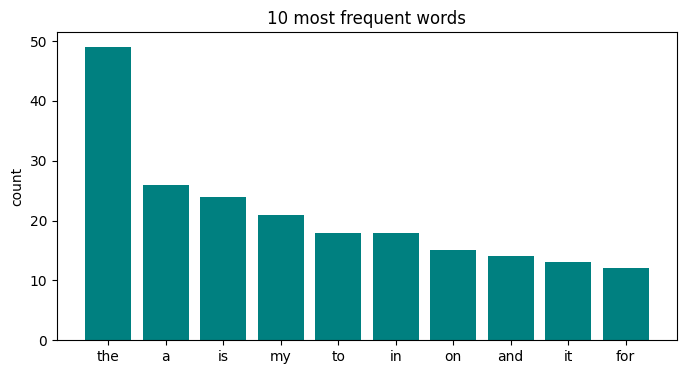

In [13]:
from collections import Counter
import matplotlib.pyplot as plt

freq = Counter(clean_words)
top = freq.most_common(10)
print(top)

plt.figure(figsize=(8,4))
plt.bar([w for w, c in top], [c for w, c in top], color='teal')
plt.title("10 most frequent words")
plt.ylabel("count")
plt.show()

### Result

| | value |
|---|---|
| Tweets collected | 100 |
| Total sentences | 197 |
| Total tokens (with punctuation) | 1346 |
| Total words (punctuation removed) | 1130 |
| Total unique words | 588 |

The tweets were collected and stored in tweets.csv, then sentence tokenization was done using `sent_tokenize` and word tokenization using `word_tokenize` from NLTK, and the three counts were calculated succesfully.

One thing i noticed is that the number of tokens is much more than the actual number of words, because punctuation marks are also tokens. So cleaning is needed before counting. Also the unique word count is far less than the total word count, that means the same common words like "the", "is", "a" are repeating a lot. These are called stop words and in the next experiments we remove them.